In [3]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import numpy as np
import argparse

import sys
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.models.trained_models import load_trained_model


Running imports...


In [7]:
run_id = '7lqisk9f'
samples_to_attribute = 'all-extr'

In [6]:
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
dataloader, lightning_model = load_trained_model(run_id)

all_targets = []
all_probas = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_probas.append(lightning_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, dataloader.config['num_timesteps_predicted'], dataloader.config['prediction_per_timestep'])
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

Seed set to 42


Data ready:
    Image size: 16380 (182x90)
    Input variables: t850, z500, v850, u850, msl
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


100%|██████████| 9/9 [00:16<00:00,  1.83s/it]


tensor([[0.5317, 0.3497, 0.1528, 0.0844, 0.2325, 0.2838, 0.1788, 0.2089, 0.3019,
         0.2051, 0.2089, 0.2615],
        [0.1398, 0.4226, 0.2928, 0.4086, 0.2099, 0.1825, 0.2608, 0.1838, 0.2141,
         0.1908, 0.1836, 0.3106],
        [0.8666, 0.2767, 0.2485, 0.0949, 0.2421, 0.2492, 0.0181, 0.2404, 0.2507,
         0.0204, 0.2409, 0.2516],
        [0.8182, 0.3351, 0.2480, 0.1728, 0.3513, 0.2492, 0.0078, 0.1567, 0.2509,
         0.0011, 0.1568, 0.2519],
        [0.6940, 0.4322, 0.2314, 0.2820, 0.2072, 0.2321, 0.0143, 0.1804, 0.2359,
         0.0097, 0.1802, 0.3005],
        [0.9772, 0.2672, 0.2415, 0.0149, 0.2512, 0.2436, 0.0038, 0.2405, 0.2448,
         0.0041, 0.2411, 0.2700],
        [0.8614, 0.3492, 0.2390, 0.1253, 0.2748, 0.2410, 0.0104, 0.1879, 0.2428,
         0.0028, 0.1881, 0.2771],
        [0.5234, 0.4140, 0.2486, 0.3402, 0.3575, 0.2500, 0.1032, 0.1143, 0.2502,
         0.0332, 0.1142, 0.2511],
        [0.4340, 0.3235, 0.2497, 0.4017, 0.3155, 0.2495, 0.1064, 0.1805, 0.2500,

In [ ]:
all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query(f"target=={dataloader.config['num_timesteps_predicted']}").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions = all_predictions.query("prediction==2 | target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")


steps = dataloader.config['num_timesteps_predicted']
predictions_attributions = all_predictions.loc[all_predictions.time_of_event.isin(time_of_attributions)].sort_values(['time_of_event','timestep'], ascending=[True, False])
start_times = predictions_attributions.query(f"timestep=={steps-1}").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = predictions_attributions.query("timestep==0").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
method = IntegratedGradients(lightning_model.model)
all_multi_attrs = []
all_multi_sens = []
for k in tqdm(range(len(start_times))):
    start = start_times[k]
    end = end_times[k]
    ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()
    attrs_0 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-3 for k in range(steps)]) 
    attrs_1 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-2 for k in range(steps)]) 
    attrs_2 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    attrs = torch.stack([attrs_0,attrs_1,attrs_2])
    da_attrs = xr.DataArray(attrs.detach(), dims = ['class_id','timestep','var_name','latitude','longitude'], 
                                coords= dict(class_id=['no-extreme','grey-zone','extreme'],timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
#     # print(start,end)
#     ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
#     tensor_in = torch.Tensor(ds_test_extract.features.values)
#     tensor_out = torch.Tensor(ds_test_extract.targets.values)
#     attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
#     da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
#                             coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
    sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))

100%|██████████| 774/774 [00:00<00:00, 1487123.82it/s]


In [ ]:
k = 10


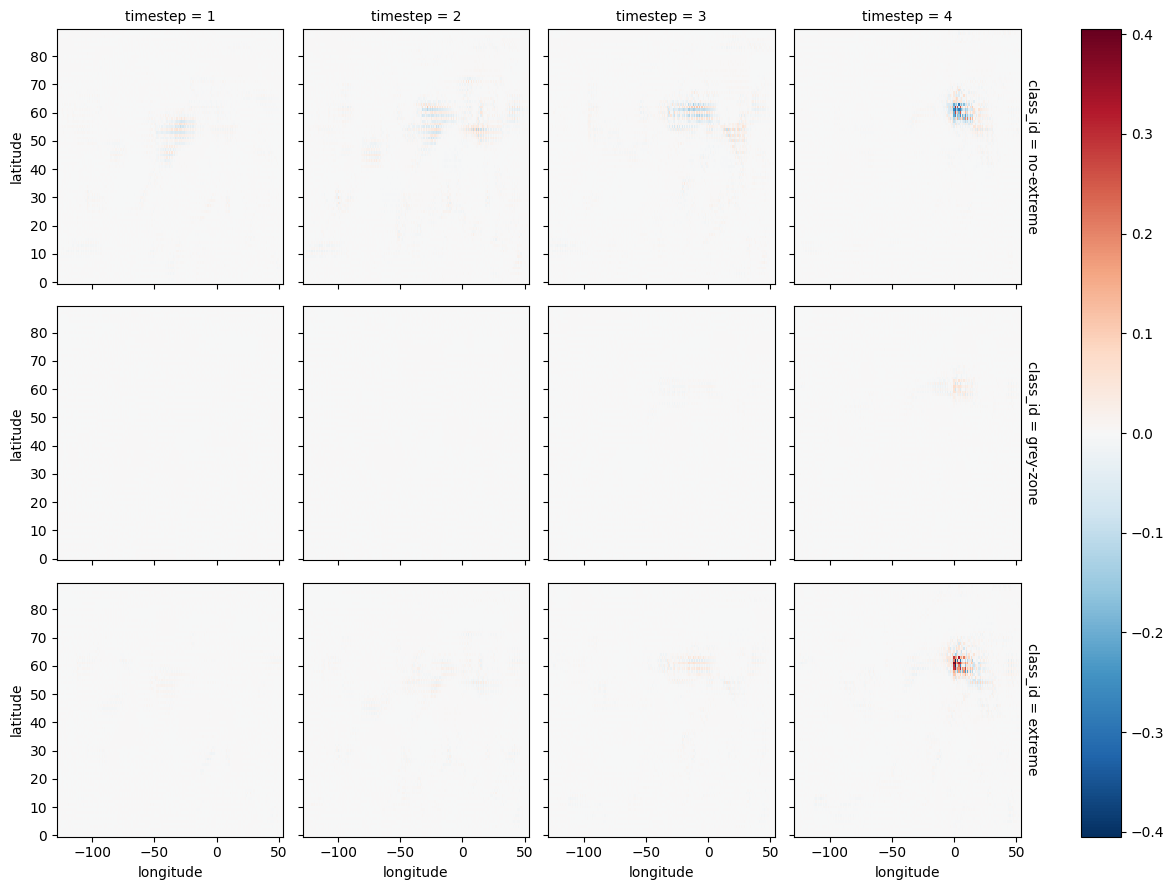

In [119]:
da_attrs.sum('var_name').plot(col='timestep', row='class_id')

In [99]:
import torch
import torch.nn.functional as F
from captum.attr import IntegratedGradients

class WrappedModel(torch.nn.Module):
    def __init__(self, model, timestep, class_idx):
        super().__init__()
        self.model = model
        self.timestep = timestep
        self.class_idx = class_idx

    def forward(self, x):
        out = self.model(x)  # shape: [batch_size, 12]
        out = out.view(-1, 4, 3)  # reshape to [batch, timesteps, classes]
        probs = F.softmax(out, dim=2)  # softmax over classes per timestep
        return probs[:, self.timestep, self.class_idx]  # shape: [batch_size]


wrapped_model = WrappedModel(lightning_model.model, timestep=2, class_idx=2)
ig = IntegratedGradients(wrapped_model)
tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()

input_tensor = tensor_in.requires_grad_()  # important!
attributions = ig.attribute(input_tensor).detach()
da_attrs = xr.DataArray(attributions, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))

In [109]:
attributions = ig.attribute(torch.zeros_like(input_tensor)).detach()


In [110]:
da_attrs.sum('var_name').sum(['longitude','latitude'])

<xarray.DataArray (timestep: 4)> Size: 16B
array([0., 0., 0., 0.], dtype=float32)
Coordinates:
  * timestep  (timestep) int64 32B 1 2 3 4

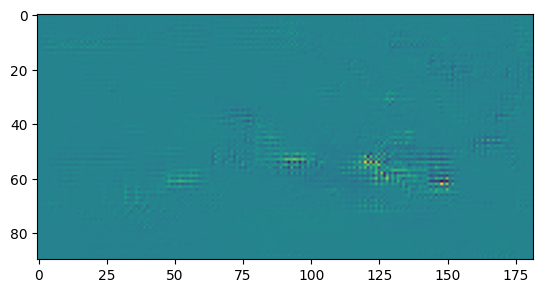

In [95]:
import matplotlib.pyplot as plt
plt.imshow(attributions.sum(dim=1)[3])

In [72]:
da_attrs.sum('var_name').sum(['longitude','latitude'])

<xarray.DataArray (class_id: 3, timestep: 4)> Size: 48B
array([[ 0.20134018,  0.09004142, -0.0354633 , -0.5514695 ],
       [ 0.0224504 ,  0.0295812 ,  0.03204483,  0.03101614],
       [-0.00972154,  0.00289331,  0.00362467,  0.00415142]],
      dtype=float32)
Coordinates:
  * class_id  (class_id) <U10 120B 'no-extreme' 'grey-zone' 'extreme'
  * timestep  (timestep) int64 32B 1 2 3 4